# Setup

In [1]:
import numpy as np
import pandas as pd
import pathlib
import pickle
import matplotlib.pyplot as plt
import json
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Definisikan Konstanta
LOOKBACK = 60
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10

PROCESSED_DIR = pathlib.Path('../data/processed')
MODELS_DIR = pathlib.Path('../models')
FIGURES_DIR = pathlib.Path('../reports/figures')

# Buat direktori jika belum ada
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Dictionary untuk menyimpan hasil
results = {}

# Load Data Array
X_train = np.load(PROCESSED_DIR / 'X_train.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')

X_val = np.load(PROCESSED_DIR / 'X_val.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy')

X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

# Load Scalers
with open(MODELS_DIR / 'scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open(MODELS_DIR / 'scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   | y_test : {y_test.shape}")


I0000 00:00:1779030274.557414   40067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779030274.557968   40067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779030274.602535   40067 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X_train: (2302, 60, 11) | y_train: (2302,)
X_val  : (235, 60, 11)   | y_val  : (235,)
X_test : (236, 60, 11)   | y_test : (236,)


I0000 00:00:1779030275.928238   40067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779030275.928570   40067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Baseline Model (Linear Regression)


In [2]:
# Reshape data 3D menjadi 2D untuk algoritma Machine Learning tradisional
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Training Baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train_2d, y_train)

# Prediksi menggunakan test set
y_pred_baseline_scaled = baseline_model.predict(X_test_2d)

# Inverse transform untuk mengembalikan nilai ke skala harga sebenarnya
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_baseline_inv = scaler_y.inverse_transform(y_pred_baseline_scaled.reshape(-1, 1)).flatten()

# Hitung Metrik
rmse_base = np.sqrt(mean_squared_error(y_test_inv, y_pred_baseline_inv))
mae_base = mean_absolute_error(y_test_inv, y_pred_baseline_inv)
mape_base = mean_absolute_percentage_error(y_test_inv, y_pred_baseline_inv) * 100

results['baseline'] = {
    'rmse': rmse_base,
    'mae': mae_base,
    'mape': mape_base,
    'predictions': y_pred_baseline_inv.tolist()
}

print("=== Hasil Metrik Baseline (Linear Regression) ===")
print(f"RMSE: Rp {rmse_base:.2f}")
print(f"MAE : Rp {mae_base:.2f}")
print(f"MAPE: {mape_base:.2f}%")


=== Hasil Metrik Baseline (Linear Regression) ===
RMSE: Rp 147.24
MAE : Rp 111.58
MAPE: 3.26%


# Model LSTM (Long Short-Term Memory)


In [3]:
# Bangun Arsitektur LSTM
model_lstm = Sequential([
    Input(shape=(LOOKBACK, 11)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

# Hitung Total Parameter LSTM untuk perbandingan
lstm_params = model_lstm.count_params()


E0000 00:00:1779030277.166248   40067 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Callback untuk EarlyStopping dan ModelCheckpoint
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODELS_DIR / 'lstm_antam.h5'), save_best_only=True, monitor='val_loss')
]

# Training LSTM
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks_lstm,
    verbose=1
)

epoch_lstm_actual = len(history_lstm.history['loss'])
print(f"\nEpoch aktual yang dijalankan (LSTM): {epoch_lstm_actual} epoch")


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0159 - mae: 0.0800

72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.0071 - mae: 0.0523 - val_loss: 0.0010 - val_mae: 0.0247
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0028 - mae: 0.0344

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0024 - mae: 0.0319 - val_loss: 7.5589e-04 - val_mae: 0.0214
Epoch 3/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0021 - mae: 0.0302

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0019 - mae: 0.0286 - val_loss: 7.0663e-04 - val_mae: 0.0215
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0019 - mae: 0.0289

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0018 - mae: 0.0279 - val_loss: 6.5162e-04 - val_mae: 0.0199
Epoch 5/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0015 - mae: 0.0258

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 7.3433e-04 - mae: 0.0179 - val_loss: 3.0802e-04 - val_mae: 0.0134
Epoch 34/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 6.5793e-04 - mae: 0.0170 - val_loss: 5.9735e-04 - val_mae: 0.0199
Epoch 35/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 6.2336e-04 - mae: 0.0169 - val_loss: 3.3103e-04 - val_mae: 0.0144
Epoch 36/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 6.9548e-04 - mae: 0.0176 - val_loss: 3.2045e-04 - val_mae: 0.0140
Epoch 37/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 6.9824e-04 - mae: 0.0172 - val_loss: 3.4719e-04 - val_mae: 0.0145
Epoch 38/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 7.2070e-04 - mae: 0.0179 - val_loss: 3.6759e-04 - val_mae: 0.0147
Epoch 39/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 5.9528e-04 - mae: 0.0161 - val_loss: 5.5425e-04 - val_mae: 0.0189
Epoch 40/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 6.6855e-04 - mae: 0.0171

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 6.2222e-04 - mae: 0.0166 - val_loss: 3.0416e-04 - val_mae: 0.0136
Epoch 41/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 7.3719e-04 - mae: 0.0183 - val_loss: 3.0491e-04 - val_mae: 0.0137
Epoch 42/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 5.9338e-04 - mae: 0.0164 - val_loss: 3.1588e-04 - val_mae: 0.0139
Epoch 43/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 5.5448e-04 - mae: 0.0159 - val_loss: 3.8081e-04 - val_mae: 0.0156
Epoch 44/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 5.3890e-04 - mae: 0.0158 - val_loss: 3.1954e-04 - val_mae: 0.0142
Epoch 45/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 6.7035e-04 - mae: 0.0170 - val_loss: 3.4941e-04 - val_mae: 0.0148
Epoch 46/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.1522e-04 - mae: 0.0151 - val_loss: 3.1406e-04 - val_mae: 0.0138
Epoch 47/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.7439e-04 - mae: 0.0164

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 6.2005e-04 - mae: 0.0166 - val_loss: 2.9859e-04 - val_mae: 0.0137
Epoch 48/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 6.2625e-04 - mae: 0.0167 - val_loss: 0.0014 - val_mae: 0.0332
Epoch 49/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 6.0419e-04 - mae: 0.0171 - val_loss: 3.4360e-04 - val_mae: 0.0148
Epoch 50/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 5.6877e-04 - mae: 0.0157

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.7990e-04 - mae: 0.0158 - val_loss: 2.9514e-04 - val_mae: 0.0135
Epoch 51/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 5.6622e-04 - mae: 0.0164 - val_loss: 3.0707e-04 - val_mae: 0.0139
Epoch 52/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 5.7662e-04 - mae: 0.0164 - val_loss: 3.7546e-04 - val_mae: 0.0150
Epoch 53/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 5.5615e-04 - mae: 0.0159 - val_loss: 2.9721e-04 - val_mae: 0.0134
Epoch 54/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 5.2819e-04 - mae: 0.0152 - val_loss: 3.5050e-04 - val_mae: 0.0149
Epoch 55/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 6.1482e-04 - mae: 0.0166 - val_loss: 4.2707e-04 - val_mae: 0.0161
Epoch 56/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 6.1547e-04 - mae: 0.0172 - val_loss: 3.0533e-04 - val_mae: 0.0138
Epoch 57/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 5.4798e-04 - mae: 0.0161

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 5.7054e-04 - mae: 0.0163 - val_loss: 2.8637e-04 - val_mae: 0.0132
Epoch 58/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 5.4495e-04 - mae: 0.0163 - val_loss: 3.5314e-04 - val_mae: 0.0151
Epoch 59/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 5.1195e-04 - mae: 0.0155 - val_loss: 3.6224e-04 - val_mae: 0.0153
Epoch 60/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 5.3461e-04 - mae: 0.0159 - val_loss: 4.5395e-04 - val_mae: 0.0174
Epoch 61/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 5.5318e-04 - mae: 0.0160 - val_loss: 3.5351e-04 - val_mae: 0.0150
Epoch 62/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 4.9459e-04 - mae: 0.0152 - val_loss: 3.0038e-04 - val_mae: 0.0137
Epoch 63/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 5.3354e-04 - mae: 0.0154 - val_loss: 0.0011 - val_mae: 0.0295
Epoch 64/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 4.8035e-04 - mae: 0.0148 - val_loss: 5.8236e-04 - val_mae: 0.0202
E

In [5]:
# Prediksi & Evaluasi pada Test Set (X_test)
y_pred_lstm_scaled = model_lstm.predict(X_test)

# Inverse transform
y_pred_lstm_inv = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

# Hitung Metrik
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
mae_lstm = mean_absolute_error(y_test_inv, y_pred_lstm_inv)
mape_lstm = mean_absolute_percentage_error(y_test_inv, y_pred_lstm_inv) * 100

results['lstm'] = {
    'rmse': rmse_lstm,
    'mae': mae_lstm,
    'mape': mape_lstm,
    'epoch': epoch_lstm_actual,
    'params': lstm_params,
    'history': history_lstm.history,
    'predictions': y_pred_lstm_inv.tolist()
}

print("=== Hasil Metrik LSTM ===")
print(f"RMSE: Rp {rmse_lstm:.2f}")
print(f"MAE : Rp {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
=== Hasil Metrik LSTM ===
RMSE: Rp 627.52
MAE : Rp 565.82
MAPE: 16.02%


# Model GRU (Gated Recurrent Unit)


In [6]:
# Bangun Arsitektur GRU yang IDENTIK dengan LSTM
model_gru = Sequential([
    Input(shape=(LOOKBACK, 11)),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_gru.summary()

# Hitung Total Parameter GRU
gru_params = model_gru.count_params()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,505 (365.25 KB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callback untuk EarlyStopping dan ModelCheckpoint
callbacks_gru = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(filepath=str(MODELS_DIR / 'gru_antam.h5'), save_best_only=True, monitor='val_loss')
]

# Training GRU
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks_gru,
    verbose=1
)

epoch_gru_actual = len(history_gru.history['loss'])
print(f"\nEpoch aktual yang dijalankan (GRU): {epoch_gru_actual} epoch")


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0319 - mae: 0.1061

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.0107 - mae: 0.0588 - val_loss: 4.9744e-04 - val_mae: 0.0172
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0022 - mae: 0.0308 - val_loss: 4.9896e-04 - val_mae: 0.0181
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0018 - mae: 0.0281 - val_loss: 5.5334e-04 - val_mae: 0.0193
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0016 - mae: 0.0260

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0015 - mae: 0.0257 - val_loss: 3.8712e-04 - val_mae: 0.0155
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0016 - mae: 0.0260

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0016 - mae: 0.0267 - val_loss: 3.4304e-04 - val_mae: 0.0147
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0014 - mae: 0.0243 - val_loss: 4.2855e-04 - val_mae: 0.0163
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0016 - mae: 0.0265 - val_loss: 6.4166e-04 - val_mae: 0.0213
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0014 - mae: 0.0239 - val_loss: 3.8994e-04 - val_mae: 0.0154
Epoch 9/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0012 - mae: 0.0224 - val_loss: 6.1180e-04 - val_mae: 0.0207
Epoch 10/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0012 - mae: 0.0228 - val_loss: 8.3188e-04 - val_mae: 0.0248
Epoch 11/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0011 - mae: 0.0213 - val_loss: 5.1622e-04 - val_mae: 0.0188
Epoch 12/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0011 - mae: 0.0212 - val_loss: 7.3263e-04 - val_mae: 0.0233
Epoch 13/100
72/72 ━━━━━━━━━━━━━━

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 8.9371e-04 - mae: 0.0193 - val_loss: 2.5105e-04 - val_mae: 0.0120
Epoch 16/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0011 - mae: 0.0214 - val_loss: 3.0963e-04 - val_mae: 0.0137
Epoch 17/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 9.1179e-04 - mae: 0.0194 - val_loss: 2.8347e-04 - val_mae: 0.0131
Epoch 18/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 8.9494e-04 - mae: 0.0192 - val_loss: 3.3769e-04 - val_mae: 0.0145
Epoch 19/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 9.0371e-04 - mae: 0.0197 - val_loss: 2.5313e-04 - val_mae: 0.0121
Epoch 20/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 7.7392e-04 - mae: 0.0179 - val_loss: 7.9680e-04 - val_mae: 0.0247
Epoch 21/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 7.5779e-04 - mae: 0.0175

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 7.1909e-04 - mae: 0.0173 - val_loss: 2.3955e-04 - val_mae: 0.0119
Epoch 22/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 8.3134e-04 - mae: 0.0188 - val_loss: 3.5705e-04 - val_mae: 0.0153
Epoch 23/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 9.0910e-04 - mae: 0.0194 - val_loss: 3.4288e-04 - val_mae: 0.0147
Epoch 24/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 9.8487e-04 - mae: 0.0203 - val_loss: 5.7629e-04 - val_mae: 0.0203
Epoch 25/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 8.9820e-04 - mae: 0.0194

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 8.4654e-04 - mae: 0.0187 - val_loss: 2.3690e-04 - val_mae: 0.0116
Epoch 26/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 7.0606e-04 - mae: 0.0176 - val_loss: 2.5697e-04 - val_mae: 0.0124
Epoch 27/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 7.4361e-04 - mae: 0.0175 - val_loss: 4.1775e-04 - val_mae: 0.0167
Epoch 28/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 7.1239e-04 - mae: 0.0177 - val_loss: 2.3872e-04 - val_mae: 0.0117
Epoch 29/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 7.6875e-04 - mae: 0.0184 - val_loss: 3.7080e-04 - val_mae: 0.0156
Epoch 30/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 7.4262e-04 - mae: 0.0180 - val_loss: 3.7103e-04 - val_mae: 0.0155
Epoch 31/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 8.5726e-04 - mae: 0.0190 - val_loss: 5.4472e-04 - val_mae: 0.0197
Epoch 32/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 7.3901e-04 - mae: 0.0177 - val_loss: 2.5166e-04 - val_mae: 0.01

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 7.2474e-04 - mae: 0.0176 - val_loss: 2.0953e-04 - val_mae: 0.0108
Epoch 34/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 7.1640e-04 - mae: 0.0177 - val_loss: 4.3915e-04 - val_mae: 0.0173
Epoch 35/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 6.5925e-04 - mae: 0.0169 - val_loss: 2.8029e-04 - val_mae: 0.0132
Epoch 36/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 6.7648e-04 - mae: 0.0172 - val_loss: 6.2982e-04 - val_mae: 0.0216
Epoch 37/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 6.2235e-04 - mae: 0.0167 - val_loss: 2.3813e-04 - val_mae: 0.0120
Epoch 38/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 6.2026e-04 - mae: 0.0164 - val_loss: 3.4372e-04 - val_mae: 0.0148
Epoch 39/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 6.0930e-04 - mae: 0.0163

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 6.5093e-04 - mae: 0.0167 - val_loss: 2.0173e-04 - val_mae: 0.0107
Epoch 40/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 7.1405e-04 - mae: 0.0174 - val_loss: 8.3087e-04 - val_mae: 0.0256
Epoch 41/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 8.3710e-04 - mae: 0.0190 - val_loss: 2.0768e-04 - val_mae: 0.0109
Epoch 42/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 6.2103e-04 - mae: 0.0164 - val_loss: 2.7124e-04 - val_mae: 0.0128
Epoch 43/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 5.9172e-04 - mae: 0.0166 - val_loss: 2.2885e-04 - val_mae: 0.0117
Epoch 44/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 7.0482e-04 - mae: 0.0176 - val_loss: 2.3040e-04 - val_mae: 0.0116
Epoch 45/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 5.7192e-04 - mae: 0.0157 - val_loss: 2.5429e-04 - val_mae: 0.0125
Epoch 46/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 6.0778e-04 - mae: 0.0163 - val_loss: 2.8863e-04 - val_mae: 0.01

In [8]:
# Prediksi & Evaluasi pada Test Set (X_test)
y_pred_gru_scaled = model_gru.predict(X_test)

# Inverse transform menggunakan scaler yang sama
y_pred_gru_inv = scaler_y.inverse_transform(y_pred_gru_scaled).flatten()

# Hitung Metrik
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))
mae_gru = mean_absolute_error(y_test_inv, y_pred_gru_inv)
mape_gru = mean_absolute_percentage_error(y_test_inv, y_pred_gru_inv) * 100

results['gru'] = {
    'rmse': rmse_gru,
    'mae': mae_gru,
    'mape': mape_gru,
    'epoch': epoch_gru_actual,
    'params': gru_params,
    'history': history_gru.history,
    'predictions': y_pred_gru_inv.tolist()
}

print("=== Hasil Metrik GRU ===")
print(f"RMSE: Rp {rmse_gru:.2f}")
print(f"MAE : Rp {mae_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
=== Hasil Metrik GRU ===
RMSE: Rp 290.48
MAE : Rp 248.57
MAPE: 7.03%


# Visualisasi Perbandingan

Bagian perbandingkan metrik pelatihan (loss curves) dan prediksi aktual pada test set dari ketiga model.


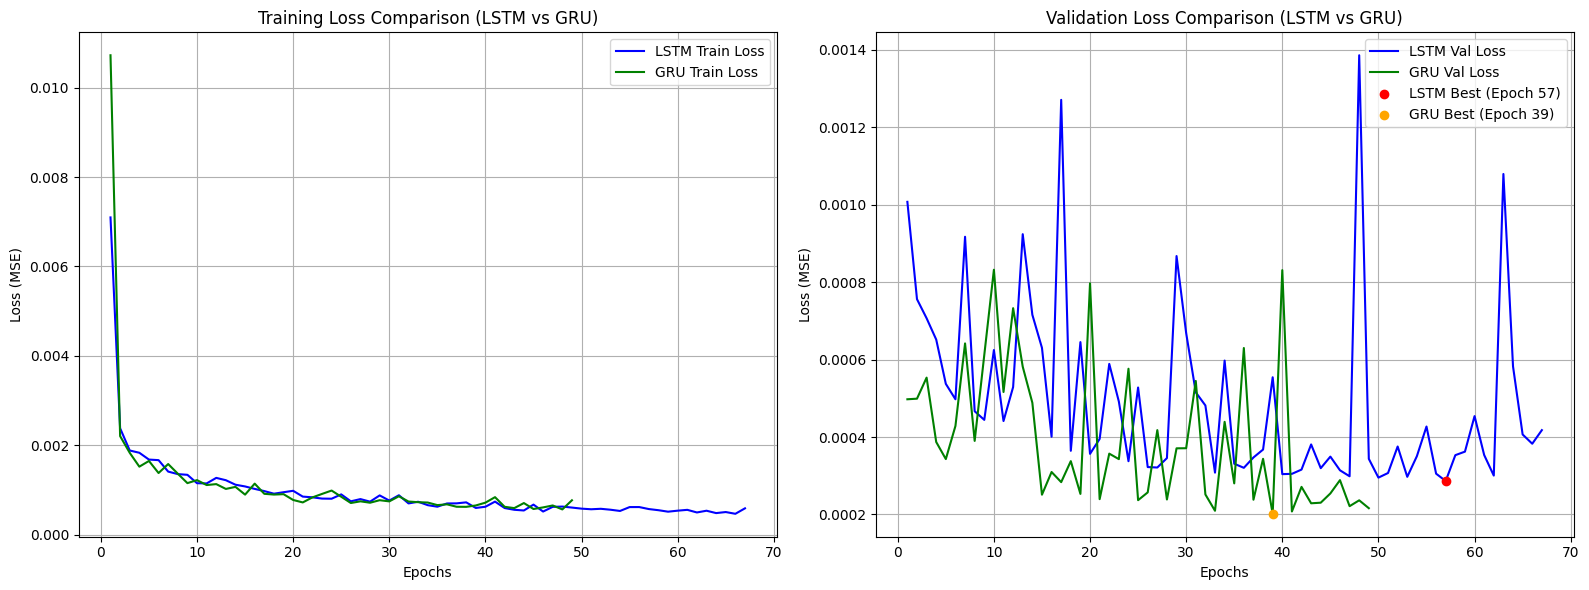

In [9]:
# Visualisasi Kurva Loss (Training vs Validation) untuk LSTM dan GRU
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_lstm = range(1, len(history_lstm.history['loss']) + 1)
epochs_gru = range(1, len(history_gru.history['loss']) + 1)

# Titik Early Stopping
es_point_lstm = np.argmin(history_lstm.history['val_loss']) + 1
es_point_gru = np.argmin(history_gru.history['val_loss']) + 1

# Plot Training Loss
axes[0].plot(epochs_lstm, history_lstm.history['loss'], label='LSTM Train Loss', color='blue')
axes[0].plot(epochs_gru, history_gru.history['loss'], label='GRU Train Loss', color='green')
axes[0].set_title('Training Loss Comparison (LSTM vs GRU)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# Plot Validation Loss
axes[1].plot(epochs_lstm, history_lstm.history['val_loss'], label='LSTM Val Loss', color='blue')
axes[1].plot(epochs_gru, history_gru.history['val_loss'], label='GRU Val Loss', color='green')
axes[1].scatter(es_point_lstm, history_lstm.history['val_loss'][es_point_lstm-1], color='red', zorder=5, label=f'LSTM Best (Epoch {es_point_lstm})')
axes[1].scatter(es_point_gru, history_gru.history['val_loss'][es_point_gru-1], color='orange', zorder=5, label=f'GRU Best (Epoch {es_point_gru})')
axes[1].set_title('Validation Loss Comparison (LSTM vs GRU)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'loss_curve_comparison.png')
plt.show()


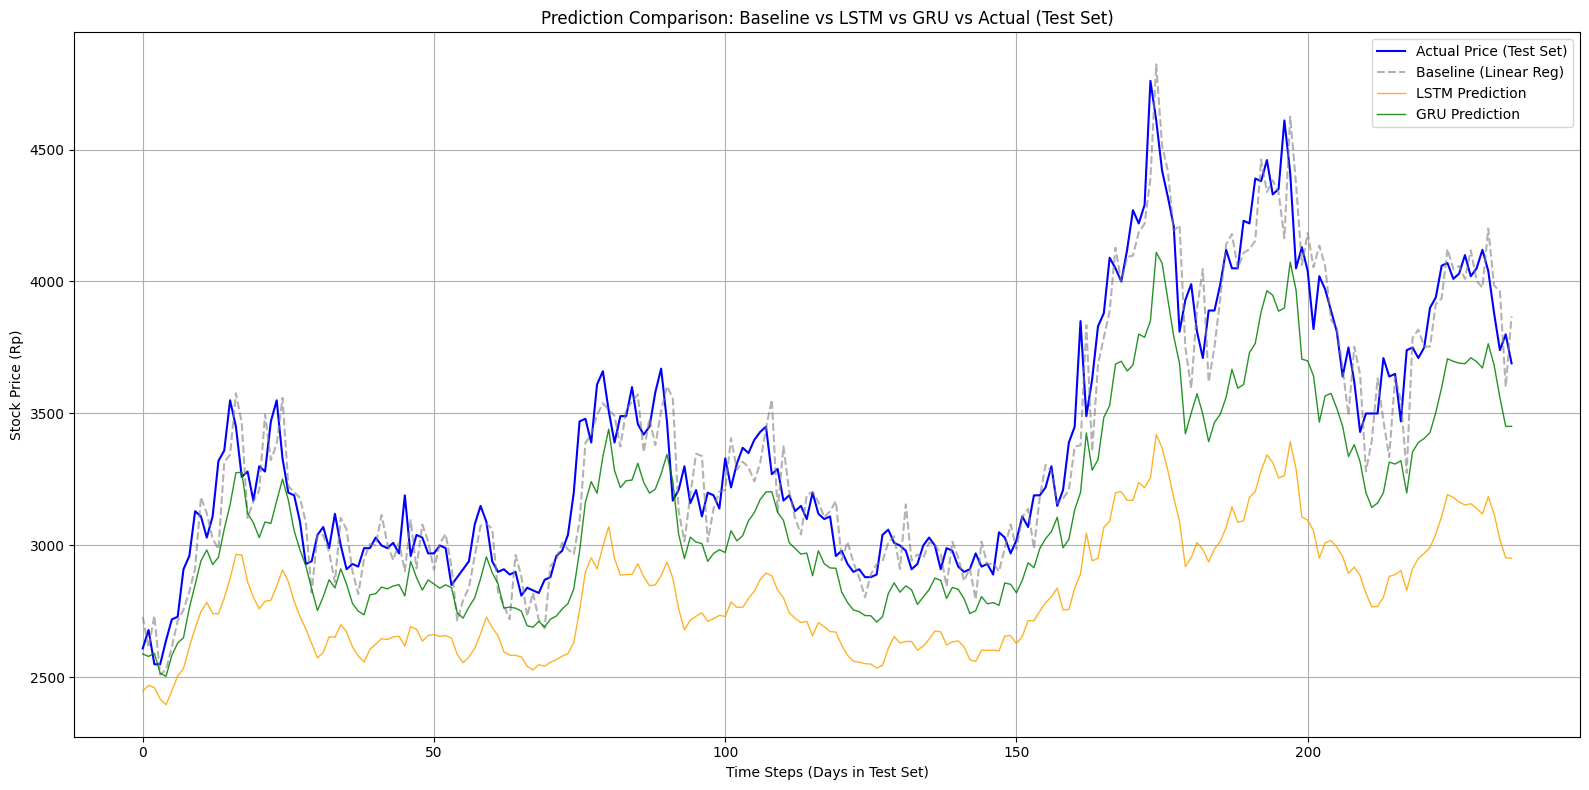

In [10]:
# Visualisasi Prediksi vs Harga Aktual pada X_test
plt.figure(figsize=(16, 8))

# Data aktual
plt.plot(y_test_inv, color='blue', linewidth=1.5, label='Actual Price (Test Set)')

# Prediksi Model
plt.plot(y_pred_baseline_inv, color='gray', linestyle='--', alpha=0.6, label='Baseline (Linear Reg)')
plt.plot(y_pred_lstm_inv, color='orange', linewidth=1, alpha=0.85, label='LSTM Prediction')
plt.plot(y_pred_gru_inv, color='green', linewidth=1, alpha=0.85, label='GRU Prediction')

plt.title('Prediction Comparison: Baseline vs LSTM vs GRU vs Actual (Test Set)')
plt.xlabel('Time Steps (Days in Test Set)')
plt.ylabel('Stock Price (Rp)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prediction_comparison.png')
plt.show()


# Tabel Perbandingan Final


In [11]:
# Konfigurasi DataFrame agar tampilan tabel lebih rapi
df_results = pd.DataFrame({
    'Model': ['Baseline', 'LSTM', 'GRU'],
    'RMSE (Rp)': [results['baseline']['rmse'], results['lstm']['rmse'], results['gru']['rmse']],
    'MAE (Rp)': [results['baseline']['mae'], results['lstm']['mae'], results['gru']['mae']],
    'MAPE (%)': [results['baseline']['mape'], results['lstm']['mape'], results['gru']['mape']],
    'Parameters': ['N/A', f"{results['lstm']['params']:,}", f"{results['gru']['params']:,}"],
    'Epochs': ['N/A', results['lstm']['epoch'], results['gru']['epoch']]
})

# Menampilkan tabel
print("=== Tabel Perbandingan Model ===")
display(df_results)

# Kalkulasi selisih spesifik LSTM vs GRU
best_model_rmse = 'LSTM' if results['lstm']['rmse'] < results['gru']['rmse'] else 'GRU'
rmse_diff = abs(results['lstm']['rmse'] - results['gru']['rmse'])
rmse_diff_pct = (rmse_diff / max(results['lstm']['rmse'], results['gru']['rmse'])) * 100

best_model_epoch = 'LSTM' if results['lstm']['epoch'] < results['gru']['epoch'] else 'GRU'
epoch_diff = abs(results['lstm']['epoch'] - results['gru']['epoch'])

param_diff = results['lstm']['params'] - results['gru']['params']
param_diff_pct = (param_diff / results['lstm']['params']) * 100

print("\n=== Analisis Lanjutan LSTM vs GRU ===")
print(f"- Dari segi akurasi (RMSE), {best_model_rmse} lebih baik dengan selisih Rp {rmse_diff:.2f} ({rmse_diff_pct:.2f}%).")
print(f"- Dari segi waktu konvergensi, {best_model_epoch} mencapai early stopping lebih cepat dengan selisih {epoch_diff} epoch.")
print(f"- Arsitektur GRU memiliki {param_diff:,} ({param_diff_pct:.2f}%) parameter lebih sedikit dibandingkan LSTM.")


=== Tabel Perbandingan Model ===


,Model,RMSE (Rp),MAE (Rp),MAPE (%),Parameters,Epochs
0,Baseline,147.244400,111.576123,3.259491,N/A,N/A
1,LSTM,627.519357,565.818367,16.017806,"123,201",67
2,GRU,290.475375,248.569536,7.025746,"93,505",49



=== Analisis Lanjutan LSTM vs GRU ===
- Dari segi akurasi (RMSE), GRU lebih baik dengan selisih Rp 337.04 (53.71%).
- Dari segi waktu konvergensi, GRU mencapai early stopping lebih cepat dengan selisih 18 epoch.
- Arsitektur GRU memiliki 29,696 (24.10%) parameter lebih sedikit dibandingkan LSTM.


In [ ]:
# Simpan results ke dalam JSON agar dapat digunakan di notebook evaluasi
json_results = {
    'baseline': {k: v for k, v in results['baseline'].items() if k not in ['predictions']},
    'lstm': {k: v for k, v in results['lstm'].items() if k not in ['history', 'predictions']},
    'gru': {k: v for k, v in results['gru'].items() if k not in ['history', 'predictions']}
}

with open(MODELS_DIR / 'results_summary.json', 'w') as f:
    json.dump(json_results, f, indent=2)
    
print(f"Results (metrik komparasi) disimpan ke {MODELS_DIR / 'results_summary.json'}")

# Simpan array hasil prediksi untuk digunakan di notebook visualisasi final
np.save(PROCESSED_DIR / 'y_test_inv.npy', y_test_inv)
np.save(PROCESSED_DIR / 'y_pred_baseline_inv.npy', y_pred_baseline_inv)
np.save(PROCESSED_DIR / 'y_pred_lstm_inv.npy', y_pred_lstm_inv)
np.save(PROCESSED_DIR / 'y_pred_gru_inv.npy', y_pred_gru_inv)
print(f"Array prediksi disimpan di {PROCESSED_DIR}")


Results (metrik komparasi) disimpan ke ../models/results_summary.json
Array prediksi disimpan di ../data/processed


# Ringkasan

1. Membangun dan melatih arsitektur model mendalam (Deep Learning): **LSTM dan GRU**. Arsitektur keduanya dirancang secara **identik** kecuali nama unit rekurensi (layer), yaitu 128 unit layer pertama, 64 unit layer kedua, Dropout 0.2, dan sebuah Dense layer 32 unit sebelum output, untuk menjamin komparasi *apple-to-apple*.
2. Membandingkannya dengan **Baseline Model (Linear Regression)** yang dievaluasi pada test set yang belum pernah dilihat model selama training. **Perhatikan bahwa evaluasi secara ketat dilakukan pada representasi test set `X_test`, bukan `X_train`**, agar dapat mengukur performa generalisasi dengan obyektif.
3. Melakukan visualisasi metrik performa (`loss curves`) yang menunjukkan titik henti terbaik (Best Epoch) melalui **Early Stopping**.

Kedua model deep learning telah disimpan:
- `models/lstm_antam.h5`
- `models/gru_antam.h5`
serta seluruh luaran metrik disimpan secara terstruktur di `models/results_summary.json`.
